### Преобразование данных датасета Titanic

In [33]:
import pandas as pd
import numpy as np

data = pd.read_csv("./train.csv")

In [34]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [36]:

data[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [37]:
data[['SibSp', 'Survived']].groupby(['SibSp'], as_index=False).mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [38]:
data[['Parch', 'Survived']].groupby(['Parch'], as_index=False).mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


In [39]:
data[['Fare', 'Survived']].groupby(['Fare'], as_index=False).mean()

,Fare,Survived
0,0.0000,0.066667
1,4.0125,0.000000
2,5.0000,0.000000
3,6.2375,0.000000
4,6.4375,0.000000
...,...,...
243,227.5250,0.750000
244,247.5208,0.500000
245,262.3750,1.000000
246,263.0000,0.500000


In [40]:
data[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


In [41]:
data[['Sex', 'Survived']].groupby(['Sex'], as_index=False).mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [42]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [43]:
data = data.drop(["PassengerId", "Name", "Age", "Ticket", "Fare", "Cabin"],axis=1)
data = pd.get_dummies(data=data, columns=['Sex', 'Embarked'], prefix=['sex', 'embarked'])

In [44]:
X = data.drop('Survived',axis=1)
y = data['Survived']

X_train, y_train, X_test, y_test = X[:int(len(X) * (7 / 10))],  \
                                    y[:int(len(X) * (7 / 10))], \
                                    X[int(len(X) * (7 / 10)):], \
                                    y[int(len(X) * (7 / 10)):]

---

### Decision Tree

In [45]:
from decision_tree import *
from utils import *

cf = {
    "max_depth" : 5,
    "min_split" : 2
}

dt = DecisionTree(cf, feature_names=X_train.columns.tolist(), mode='classification')
dt.fit(np.array(X_train), np.array(y_train))

print("Дерево решений:")
dt.print_feature_importance()

print("\nПороги для фичей:")
feature_thresholds = dt.get_feature_thresholds()
for feature, thresholds in feature_thresholds.items():
    print(f"{feature}: {thresholds}")

y_pred = dt.predict(np.array(X_test))

print("Accuracy: {}".format(accuracy(np.array(y_test), y_pred)))
print("Precision: {}".format(precision(np.array(y_test), y_pred)))
print("Recall: {}".format(recall(np.array(y_test), y_pred)))
print("Avg harmonical: {}".format(avg_harmonical(np.array(y_test), y_pred)))

Дерево решений:
Decision: sex_female <= 0.000
|-- True:
|  Decision: Pclass <= 1.000
|  |-- True:
|  |  Decision: Parch <= 1.000
|  |  |-- True:
|  |  |  Decision: SibSp <= 0.000
|  |  |  |-- True:
|  |  |  |  Decision: embarked_C <= 0.000
|  |  |  |  |-- True:
|  |  |  |  |  Leaf: class=0
|  |  |  |  |__ False:
|  |  |  |     Leaf: class=0
|  |  |  |__ False:
|  |  |     Decision: embarked_C <= 0.000
|  |  |     |-- True:
|  |  |     |  Leaf: class=0
|  |  |     |__ False:
|  |  |        Leaf: class=1
|  |  |__ False:
|  |     Decision: SibSp <= 1.000
|  |     |-- True:
|  |     |  Decision: Parch <= 2.000
|  |     |  |-- True:
|  |     |  |  Leaf: class=1
|  |     |  |__ False:
|  |     |     Leaf: class=0
|  |     |__ False:
|  |        Leaf: class=0
|  |__ False:
|     Decision: Parch <= 0.000
|     |-- True:
|     |  Decision: embarked_C <= 0.000
|     |  |-- True:
|     |  |  Decision: embarked_Q <= 0.000
|     |  |  |-- True:
|     |  |  |  Leaf: class=0
|     |  |  |__ False:
|

---

### Random Forest

In [46]:
from random_forest import *
from utils import *

cf = {
    "max_depth" : 5,
    "min_split" : 2
}

rf = RandomForestClassifier(50, num_features="sqrt",cf=cf)
rf.fit(np.array(X_train),np.array(y_train))

y_pred = rf.predict(np.array(X_test))

print("Accuracy: {}".format(accuracy(np.array(y_test), y_pred)))
print("Precision: {}".format(precision(np.array(y_test), y_pred)))
print("Recall: {}".format(recall(np.array(y_test), y_pred)))
print("Avg harmonical: {}".format(avg_harmonical(np.array(y_test), y_pred)))

Accuracy: 0.7902621722846442
Precision: 0.5729166666666666
Recall: 0.7746478873239436
Avg harmonical: 0.6586826347305389


---

### Linear Classification

In [47]:
from linear_classifier import *

lc = LinearClassifier()
lc.fit(np.array(X_train), np.array(y_train))

y_pred = lc.predict(np.array(X_test))

print("Accuracy: {}".format(accuracy(np.array(y_test), y_pred)))
print("Precision: {}".format(precision(np.array(y_test), y_pred)))
print("Recall: {}".format(recall(np.array(y_test), y_pred)))
print("Avg harmonical: {}".format(avg_harmonical(np.array(y_test), y_pred)))

Accuracy: 0.7902621722846442
Precision: 0.625
Recall: 0.7407407407407407
Avg harmonical: 0.6779661016949152


---

### KNN Classifier

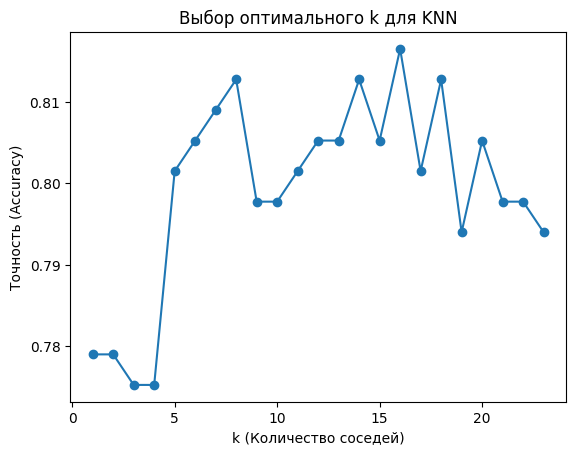

Best k is: 16
Accuracy: 0.8164794007490637
Precision: 0.59375
Recall: 0.8382352941176471
Avg harmonical: 0.6951219512195121


In [51]:
import matplotlib.pyplot as plt
from knn import *

acc_score = []
k_vals = range(1, int(np.sqrt(np.array(X_train).shape[0])))
for k in k_vals:
    knnc = KNNClassifier(k)
    knnc.fit(np.array(X_train), np.array(y_train))
    y_pred = knnc.predict(np.array(X_test))
    acc_score.append(accuracy(np.array(y_test), y_pred))

plt.plot(k_vals, acc_score, marker='o')
plt.xlabel('k (Количество соседей)')
plt.ylabel('Точность (Accuracy)')
plt.title('Выбор оптимального k для KNN')
plt.show()

best_k = k_vals[np.argmax(acc_score)]
print(f'Best k is: {best_k}')

knnc = KNNClassifier(best_k)
knnc.fit(np.array(X_train), np.array(y_train))

y_pred = knnc.predict(np.array(X_test))

print("Accuracy: {}".format(accuracy(np.array(y_test), y_pred)))
print("Precision: {}".format(precision(np.array(y_test), y_pred)))
print("Recall: {}".format(recall(np.array(y_test), y_pred)))
print("Avg harmonical: {}".format(avg_harmonical(np.array(y_test), y_pred)))


---

### Decision Tree for regression

In [ ]:
import matplotlib.pyplot as plt
from decision_tree import *
from utils import *

train_df = pd.read_csv("./train_reg.csv")

y = z_score_normalizer(np.array(train_df["SalePrice"]))
X = train_df.drop(["Id", "SalePrice"], axis=1)
X = X.select_dtypes(include=['float64', 'int64']).fillna(0)
X = z_score_normalizer(X)

X = np.array(X)
y = np.array(y)

X_train, y_train, X_test, y_test = X[:int(len(X) * (7 / 10))],  \
                                    y[:int(len(X) * (7 / 10))], \
                                    X[int(len(X) * (7 / 10)):], \
                                    y[int(len(X) * (7 / 10)):]

cf = {
    "max_depth" : 5,
    "min_split" : 2
}

dt = DecisionTree(cf, mode='regression')
dt.fit(np.array(X_train), np.array(y_train))

y_p = dt.predict(X_test)

print(f"MSE {mse_metric(y_test, y_p)}")
print(f"RMSE {rmse_metric(y_test, y_p)}")
print(f"MAE {mae_metric(y_test, y_p)}")
print(f"MAPE {mape_metric(y_test, y_p)}")

plt.scatter(y_test, y_p, 2)
plt.plot(y_p, y_p, "r")
plt.show()


---

### Random Forest regression

In [ ]:
from random_forest import *

cf = {
    "max_depth" : 5,
    "min_split" : 2
}

rf = RandomForestClassifier(50, num_features="sqrt",cf=cf, mode="regression")
rf.fit(X_train, y_train)

y_p = rf.predict(X_test)

print(f"MSE {mse_metric(y_test, y_p)}")
print(f"RMSE {rmse_metric(y_test, y_p)}")
print(f"MAE {mae_metric(y_test, y_p)}")
print(f"MAPE {mape_metric(y_test, y_p)}")
plt.scatter(y_test, y_p, 2)
plt.plot(y_p, y_p, "r")
plt.show()